# Retail Inventory Management Analysis

This notebook analyzes retail stock levels and identifies fast-moving items using summary statistics from the `Retail inventory.csv` dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting style for plotting
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading

Load the dataset and take a first look at the data.

In [2]:
# Load dataset
df = pd.read_csv('Retail inventory.csv')

# Basic information about the dataset
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Store                             499 non-null    int64  
 1   Date                              499 non-null    object 
 2   Product                           499 non-null    object 
 3   Weekly_Sales                      499 non-null    float64
 4   inventory level                   499 non-null    int64  
 5   Temperature                       499 non-null    float64
 6   Past promotion of product in lac  499 non-null    float64
 7   demand forecast                   499 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 31.3+ KB
None


,Store,Date,Product,Weekly_Sales,inventory level,Temperature,Past promotion of product in lac,demand forecast
0,1,05-02-2010,Blueberry scented candle,1643690.90,0,42.31,2.572,8.106
1,4,12-02-2010,Stainless steel water bottle,1641957.44,1,38.51,2.548,8.106
2,5,19-02-2010,Leather messenger bag,1611968.17,0,39.93,2.514,8.106
3,2,26-02-2010,Organic coconut oil,1409727.59,0,46.63,2.561,8.106
4,3,05-03-2010,Bluetooth wireless earbuds,1554806.68,0,46.50,2.625,8.106


## 2. Summary Statistics

Analyze the summary statistics of the numerical columns.

In [3]:
# Descriptive statistics
summary_stats = df.describe()
summary_stats

,Store,Weekly_Sales,inventory level,Temperature,Past promotion of product in lac,demand forecast
count,499.000000,4.990000e+02,499.00000,499.000000,499.000000,499.000000
mean,2.903808,1.393897e+06,0.07014,67.766673,3.179545,7.434138
std,1.379266,6.752128e+05,0.25564,14.773289,0.433265,0.584243
min,1.000000,3.395974e+05,0.00000,28.840000,2.514000,5.946000
25%,2.000000,4.443598e+05,0.00000,56.660000,2.728000,7.092000
50%,3.000000,1.614259e+06,0.00000,69.310000,3.256000,7.551000
75%,4.000000,1.880827e+06,0.00000,80.770000,3.571000,7.866000
max,5.000000,3.526713e+06,1.00000,93.340000,3.907000,8.623000


## 3. Stock Level Analysis

We investigate the distribution of `inventory level` across the dataset.

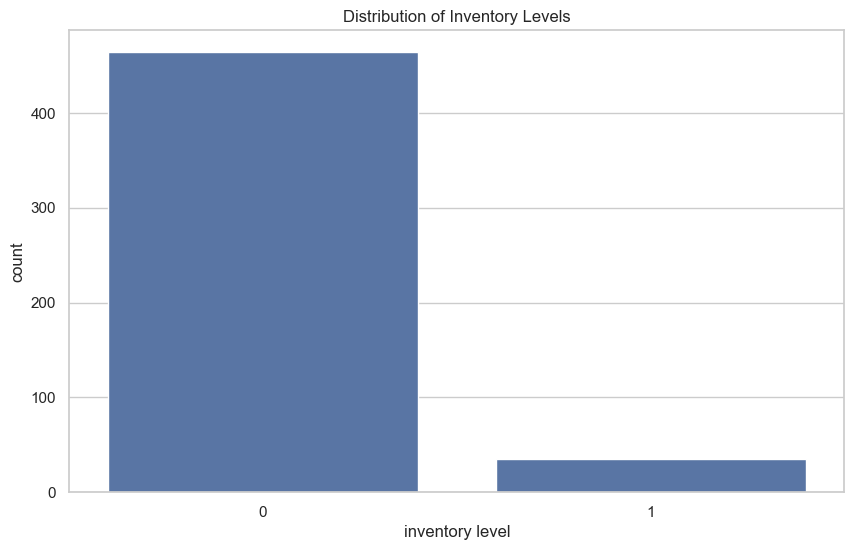

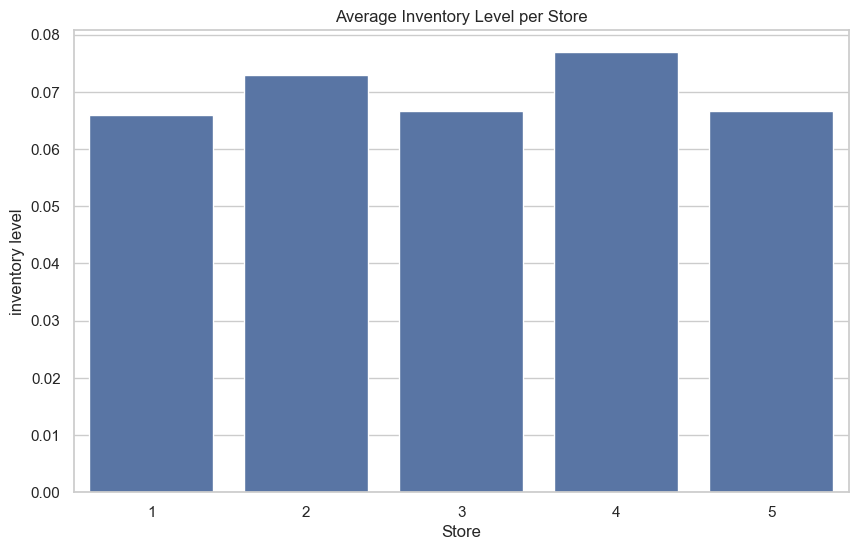

In [4]:
# Distribution of Inventory Levels
sns.countplot(data=df, x='inventory level')
plt.title('Distribution of Inventory Levels')
plt.show()

# Average inventory level per Store
store_inventory = df.groupby('Store')['inventory level'].mean().reset_index()
sns.barplot(data=store_inventory, x='Store', y='inventory level')
plt.title('Average Inventory Level per Store')
plt.show()

## 4. Identifying Fast-Moving Items

Fast-moving items are products with high `Weekly_Sales` volume.

C:\Users\yashw\AppData\Local\Temp\ipykernel_12596\621418953.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_items, y='Product', x='Weekly_Sales', palette='viridis')


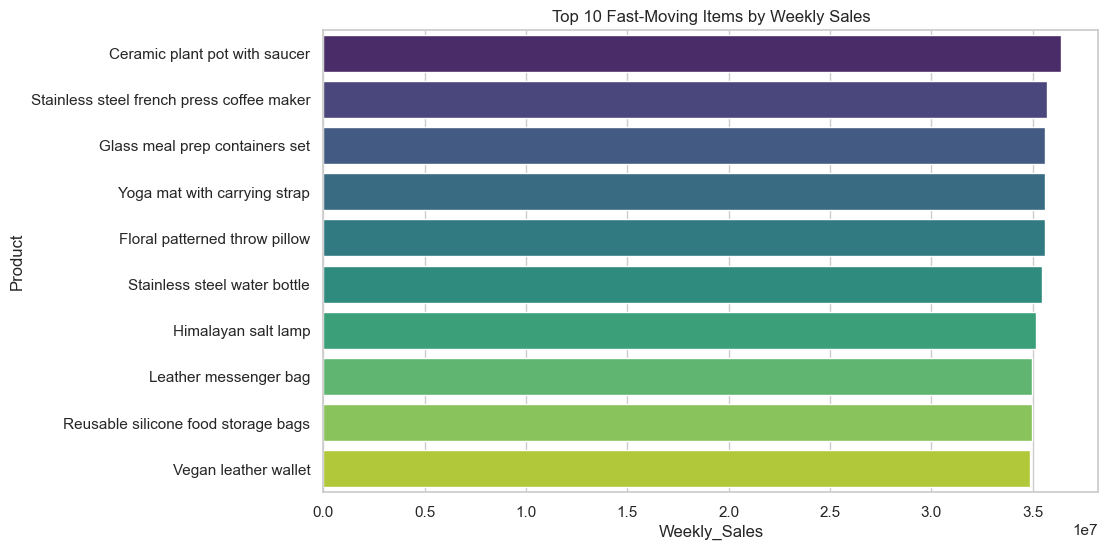

Top 5 products by total sales:
                                     Product  Weekly_Sales
0              Ceramic plant pot with saucer   36417854.76
1  Stainless steel french press coffee maker   35727382.64
2             Glass meal prep containers set   35628798.85
3               Yoga mat with carrying strap   35620615.76
4              Floral patterned throw pillow   35589856.29


In [5]:
# Top 10 Fast-Moving Items (by total Sales)
fast_moving_items = df.groupby('Product')['Weekly_Sales'].sum().sort_values(ascending=False).reset_index()
top_10_items = fast_moving_items.head(10)

sns.barplot(data=top_10_items, y='Product', x='Weekly_Sales', palette='viridis')
plt.title('Top 10 Fast-Moving Items by Weekly Sales')
plt.show()

print("Top 5 products by total sales:")
print(top_10_items.head(5))

## 5. Data Processing Enhancements

Convert `Date` to explicitly typed datetime objects to enable time-series operations, and extract Month and Year features.

In [6]:
# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values(by='Date')

# Feature Engineering: Extract Month and Year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

## 6. Time-Series Trend Analysis

Analyze how `Weekly_Sales` fluctuate over time to observe seasonality and overall trend performance.

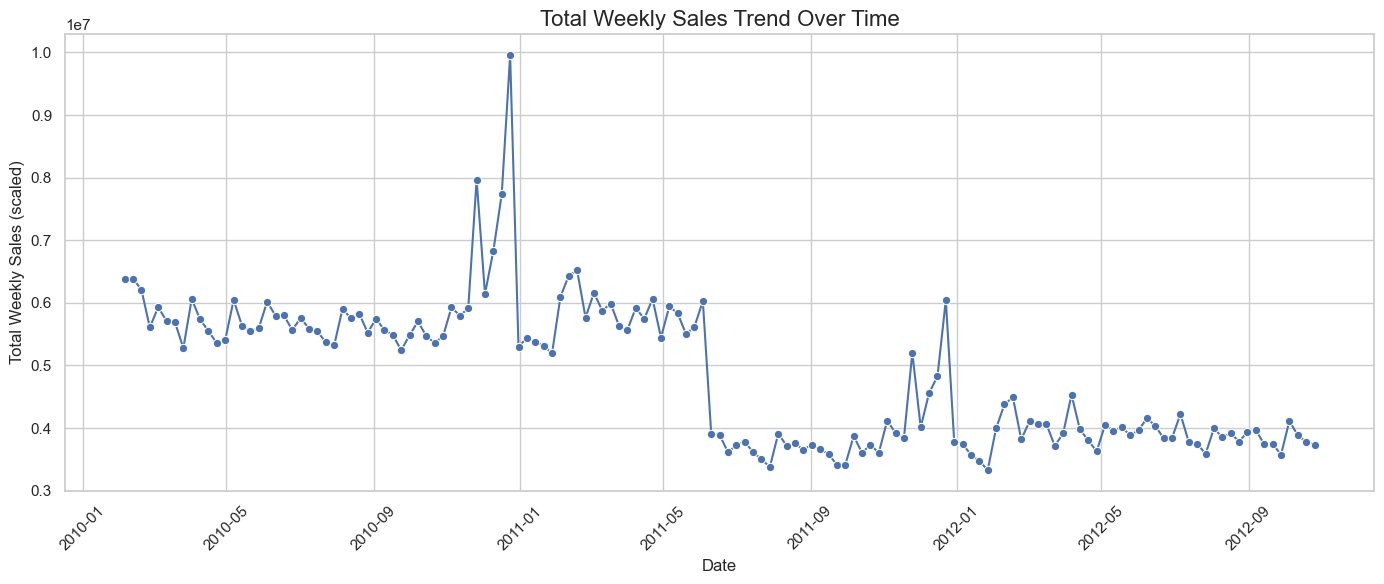

In [7]:
# Aggregate weekly sales over time
weekly_sales_trend = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_sales_trend, x='Date', y='Weekly_Sales', marker='o', color='b')
plt.title('Total Weekly Sales Trend Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Weekly Sales (scaled)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Correlation Analysis & Heatmap

Investigate multidimensional relationships between the dataset's numerical variables using a Pearson correlation matrix.

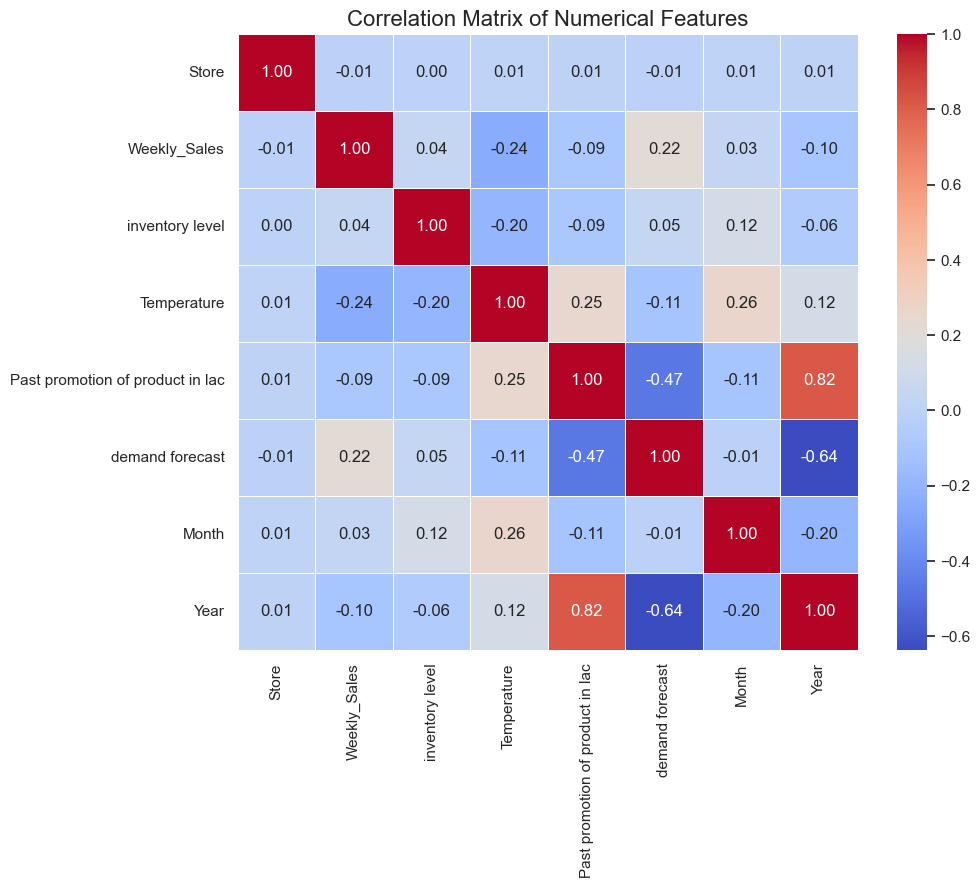

In [8]:
# Select numeric columns for correlation analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

## 8. Demand Forecast Evaluation

Evaluate the accuracy of expected historical demand against actual weekly sales revenue using a regression scatter plot.

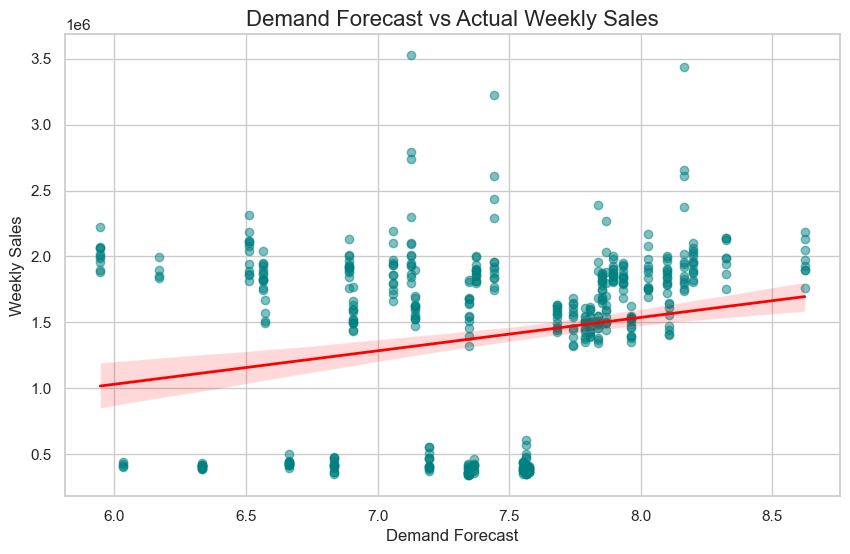

In [9]:
# Scatter plot with regression line evaluating forecast vs real sales
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='demand forecast', y='Weekly_Sales', scatter_kws={'alpha':0.5, 'color': 'teal'}, line_kws={'color':'red', 'lw': 2})
plt.title('Demand Forecast vs Actual Weekly Sales', fontsize=16)
plt.xlabel('Demand Forecast', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.show()

## Conclusion

Based on the analysis, we've identified the top fast-moving products and the overall inventory levels across stores.